In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


# Diabetes and Pima Indian Dataset

* Machine learning has become an important approach to many researches today. It is a field of artificial intelligence and its importance is increasing day by day. 

* In this project, a classification model will be made using the Pima Indians Diabetes data set. Diabetes is a group of metabolic disorders in which long-term high blood sugar levels are seen. High blood sugar symptoms include frequent urination, increased thirst, and increased hunger. If left untreated, diabetes can cause many complications. Acute complications may include diabetic ketoacidosis, hyperosmolar hyperglycemic state, or death. Serious long-term complications include cardiovascular disease, stroke, chronic kidney disease, foot ulcer, and eye damage. 

* This dataset was originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The purpose of the dataset is to diagnostically predict whether a patient has diabetes based on the specific diagnostic measures included in the data set. Various restrictions have been imposed on the selection of these samples from a larger database. 

* In particular, all the patients here are women who are at least 21 years old of Pima Indian heritage. The data set consists of 768 observation units and 9 variables. These variables are; pregnancy, glucose, blood pressure, skin thickness, insulin, body mass index, diabetes pedigree, age and outcome. After the exploratory data analysis on the data set is completed, the machine learning model will be set up. For this, supervised learning algorithms will be used. 

1. **Pregnancies:** Number of times pregnant
2. **Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test
3. **BloodPressure:** Diastolic blood pressure (mm Hg)
4. **SkinThickness:** Triceps skin fold thickness (mm)
5. **Insulin:** 2-Hour serum insulin (mu U/ml)
6. **BMI:** Body mass index (weight in kg/(height in m)^2)
7. **DiabetesPedigreeFunction:** Diabetes pedigree function
8. **Age:** Age (years)
9. **Outcome:** Class variable (0 or 1)

# Importing Libraries

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
import missingno as msno
import warnings
warnings.filterwarnings("ignore")

# Reading Data

In [3]:
diabetes = pd.read_csv("../input/pima-indians-diabetes-database/diabetes.csv")
df = diabetes.copy()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In this dataset missing data are filled with 0. First, we are gonna change zeros with NaN

In [6]:
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness',
                                                                      'Insulin','BMI']].replace(0, np.NaN)

# Data Visualization

### Histogram
A histogram is a bar graph representation of a grouped data distribution. In other words, it is the transfer of data consisting of repetitive numbers to the table first, and to the chart by using the table, in other words, the graph of the data groups is displayed in rectangular columns.

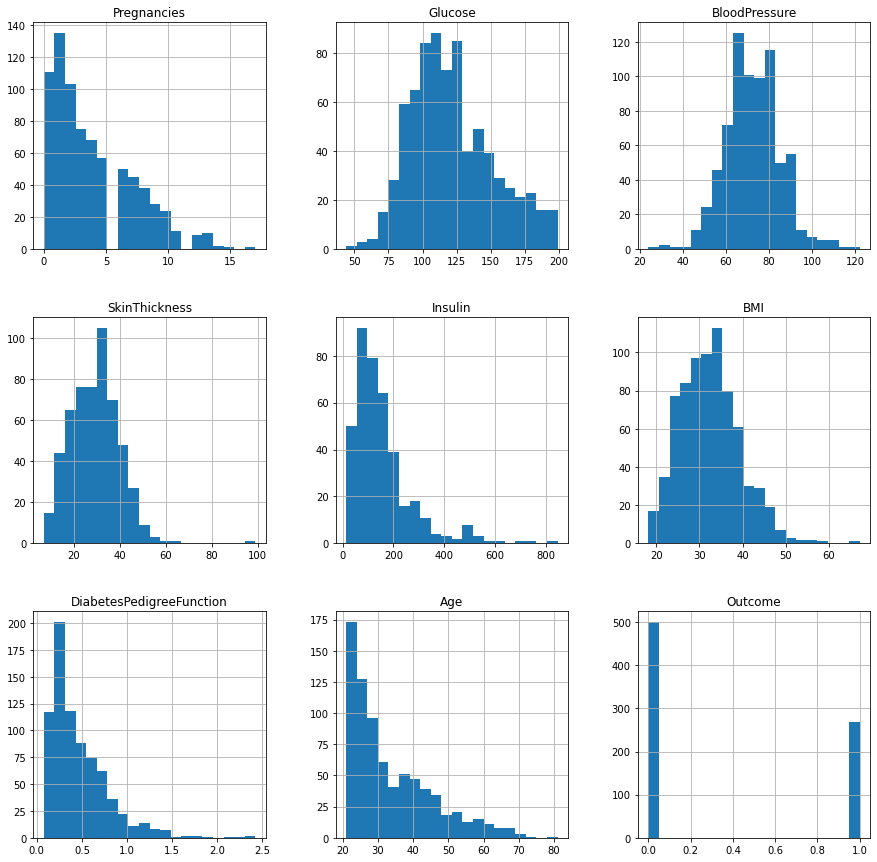

In [7]:
df.hist(bins=20,figsize = (15,15));

### Countplot and PiePlot
A count plot can be thought of as a histogram across a categorical, instead of quantitative, variable. A Pie Chart is a type of graph that displays data in a circular graph. The pieces of the graph are proportional to the fraction of the whole in each category. 

We examined distribution of outcome with countplot and pieplot. 

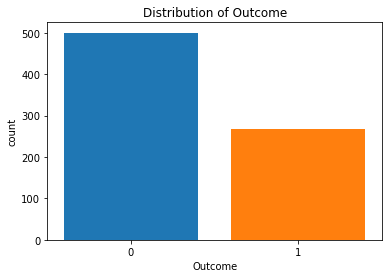

In [8]:
plt.title("Distribution of Outcome")
sns.countplot(df["Outcome"], saturation=1)

In [9]:
def PlotPie(df, nameOfFeature):
    labels = [str(df[nameOfFeature].unique()[i]) for i in range(df[nameOfFeature].nunique())]
    values = [df[nameOfFeature].value_counts()[i] for i in range(df[nameOfFeature].nunique())]

    trace=go.Pie(labels=labels,values=values)

    py.iplot([trace])

PlotPie(df, "Outcome")

### Correlation
Correlation is a term that is a measure of the strength of a linear relationship between two quantitative variables.

In this graph, there are correlations of all variables with the Outcome variable.

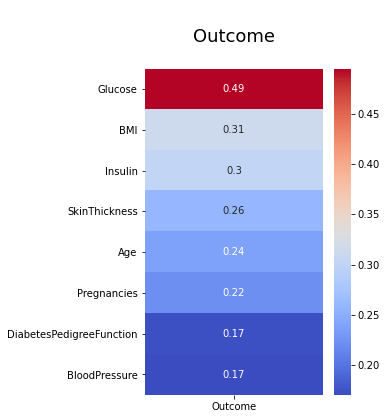

In [10]:
def corr_to_target(dataframe, target, title=None, file=None):
    plt.figure(figsize=(4,6))
    sns.heatmap(dataframe.corr()[[target]].sort_values(target,
                                                        ascending=False)[1:],
                                                        annot=True,
                                                        cmap='coolwarm')
    
    plt.title(f'\n{title}\n', fontsize=18)
    
    plt.show();
    
    return

corr_to_target(df, "Outcome", title="Outcome")

Correlation matrix of variables with each other.

Text(0.5, 1.0, 'Correlation Between Features')

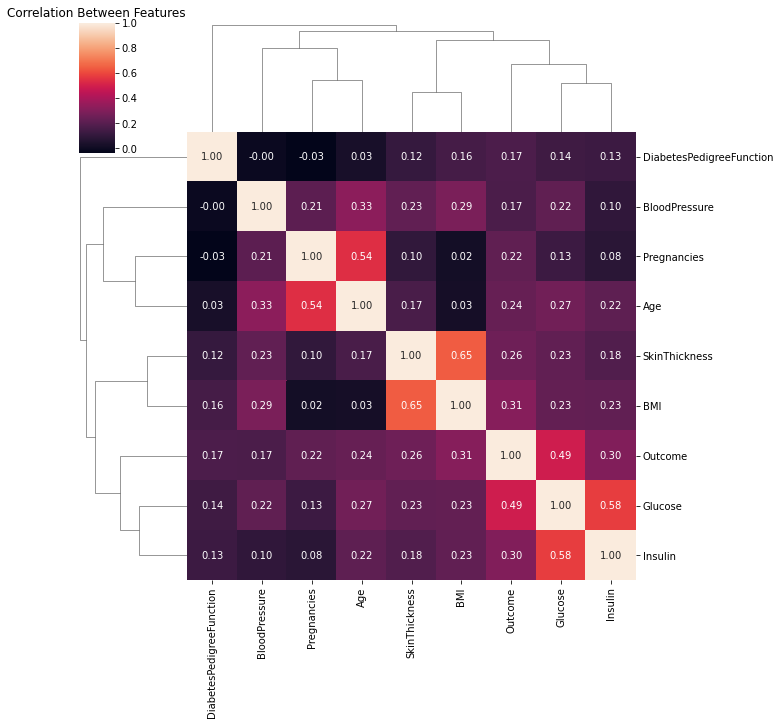

In [11]:
corr_matrix = df.corr()
sns.clustermap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Between Features")

# Splitting Train and Test Set

Above, we first gave all variables except the "outcome" variable to the X variable and gave the variable "outcome" to the y variable. Then we split the data into train and test data. X_train and y_train show the dependent and independent variables to be used to test the model, while X_test and y_test are used to develop the model. Test_size specifies how many% of data (30%) will be used for testing. Random_state is used to see the same distinction every time we run the program. Stratify provides a balanced separation of classes in the y variable when separating.

In [12]:
#y = df["Outcome"]
#X = df.drop(["Outcome"], axis = 1)
train,test = train_test_split(df, test_size=0.3, random_state = 2)

In [13]:
train.isnull().sum()

Pregnancies                   0
Glucose                       2
BloodPressure                22
SkinThickness               162
Insulin                     256
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [14]:
test.isnull().sum()

Pregnancies                   0
Glucose                       3
BloodPressure                13
SkinThickness                65
Insulin                     118
BMI                           4
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Handling with Missing Values

After filling the 0s with the value of NaN, the missing values ​​will be visualized. We use the missingno library for this.

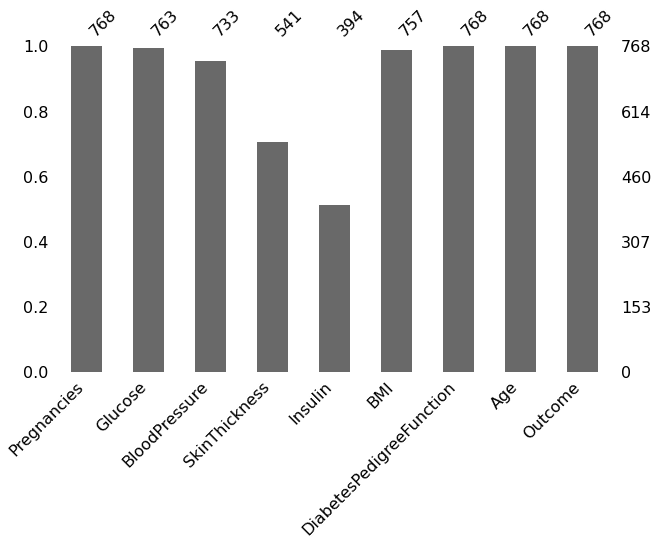

In [15]:
msno.bar(df,figsize=(10,6))

We will fill in each missing value with its median value.

In [16]:
def median_target(dataf, var):   
    temp = dataf[dataf[var].notnull()]
    temp = temp[[var, 'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    return temp

In [17]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
for i in columns:
    train.loc[(train['Outcome'] == 0 ) & (train[i].isnull()), i] = median_target(train,i)[i][0]
    train.loc[(train['Outcome'] == 1 ) & (train[i].isnull()), i] = median_target(train,i)[i][1]
    
    test.loc[(test['Outcome'] == 0 ) & (test[i].isnull()), i] = median_target(train,i)[i][0]
    test.loc[(test['Outcome'] == 1 ) & (test[i].isnull()), i] = median_target(train,i)[i][1]

After filling if we examine null values in dataset, we will see there are not any missing values.

In [18]:
print("TRAIN DATA")
print(train.isnull().sum(), "\n")
print("TEST DATA")
print(test.isnull().sum())

TRAIN DATA
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64 

TEST DATA
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# Plotting Roc Curve

ROC curves are frequently used to show in a graphical way the connection/trade-off between clinical sensitivity and specificity for every possible cut-off for a test or a combination of tests. In addition the area under the ROC curve gives an idea about the benefit of using the test(s) in question.

In [19]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1],[0,1],"k--")
    plt.axis([0,1,0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

# Machine Learning

We will use 6 different machine learning algorithm for this model and examine ROC score, accuracy test and train score, best parameters and ROC curve

In [20]:
X_train = train.iloc[:,:8]
y_train = train.iloc[:,-1:]

X_test = test.iloc[:,:8]
y_test = test.iloc[:,-1:]

In [21]:
def ml_model(model, parameters):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
    random_search = RandomizedSearchCV(model, parameters, cv=cv, random_state=1, n_jobs=-1, verbose=1)
    pipe = make_pipeline(StandardScaler(),random_search)
    pipe.fit(X_train, y_train)
    y_pred_proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    print("ROC Score : ",roc_auc_score(y_test, y_pred_proba))
    print("F1 score for train: ", f1_score(y_train, pipe.predict(X_train)))
    print("F1 score for test: " , f1_score(y_test, pipe.predict(X_test)))
    print("Best params:" + str(random_search.best_params_))
    plot_roc_curve(fpr, tpr)
    
log_reg_params = {"C" : [1,2,3,0.01,0.001, 2.5, 1.5],
                  "max_iter" : range(100,800,100)}
knn_params = {"n_neighbors" : np.arange(1,50),
              "leaf_size" : np.arange(1,50)}
decTree_params = {"max_depth" : [5,10,15,20,25,30],
                  "min_samples_split" : np.arange(2,50),
                  "min_samples_leaf" : np.arange(1,50)}
randomForest_params = {"n_estimators" : [100,500, 1000],
                       "min_samples_split" : np.arange(2,30),
                       "min_samples_leaf" : np.arange(1,50),
                       "max_features" : np.arange(1,7)}
lgbm_params = {"n_estimators" : [100,500,1000],
               "subsample" : [0.6,0.8,1.0],
               "max_depth" : [5,10,15,20,25,30],
               "learning_rate" : [0.1, 0.01, 0.02, 0.5],
               "min_child_samples" : np.arange(2,30)}

sgd_params = {"alpha" : [0.0001, 0.1, 0.001, 0.01],
              "max_iter" : [100,500,1000,2000],
              "loss" : ["log","modified_huber","perceptron"]}

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:    2.2s


ROC Score :  0.8506791171477079
F1 score for train:  0.6523076923076924
F1 score for test:  0.5573770491803278
Best params:{'max_iter': 700, 'C': 0.01}


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    4.4s finished


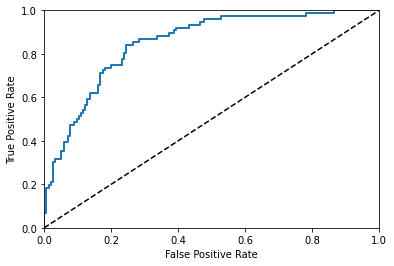

In [22]:
ml_model(LogisticRegression(), log_reg_params)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:    1.1s


ROC Score :  0.8732173174872666
F1 score for train:  0.7647058823529411
F1 score for test:  0.7007299270072993
Best params:{'n_neighbors': 19, 'leaf_size': 23}


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    3.4s finished


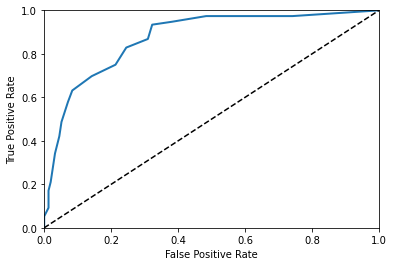

In [23]:
ml_model(KNeighborsClassifier(), knn_params)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 312 tasks      | elapsed:    0.8s


ROC Score :  0.9217741935483872
F1 score for train:  0.8385542168674699
F1 score for test:  0.8104575163398693
Best params:{'min_samples_split': 13, 'min_samples_leaf': 33, 'max_depth': 25}


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    1.9s finished


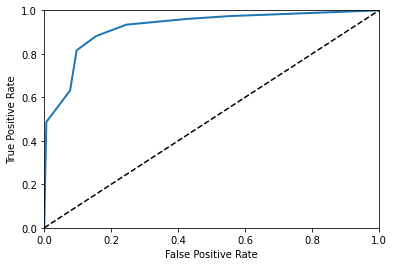

In [24]:
ml_model(DecisionTreeClassifier(), decTree_params)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  9.1min finished


ROC Score :  0.9319185059422751
F1 score for train:  0.8762886597938144
F1 score for test:  0.7801418439716312
Best params:{'n_estimators': 1000, 'min_samples_split': 24, 'min_samples_leaf': 13, 'max_features': 2}


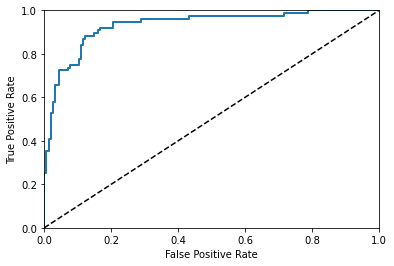

In [25]:
ml_model(RandomForestClassifier(), randomForest_params)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 528 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-1)]: Done 982 tasks      | elapsed:   57.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   58.7s finished


ROC Score :  0.9473684210526316
F1 score for train:  0.8937329700272479
F1 score for test:  0.8059701492537312
Best params:{'subsample': 1.0, 'n_estimators': 100, 'min_child_samples': 24, 'max_depth': 20, 'learning_rate': 0.02}


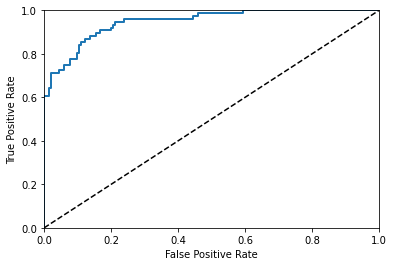

In [26]:
ml_model(LGBMClassifier(), lgbm_params)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 312 tasks      | elapsed:    0.9s


ROC Score :  0.8419354838709677
F1 score for train:  0.6778711484593837
F1 score for test:  0.6015037593984963
Best params:{'max_iter': 100, 'loss': 'log', 'alpha': 0.01}


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    2.0s finished


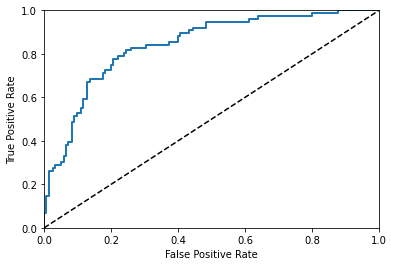

In [27]:
ml_model(SGDClassifier(), sgd_params)